In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import sys, os
sys.path.append("../../src/")

import scipy.stats as stats
from tqdm import tqdm
from baseline_network import BaselineNetwork

In [3]:
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'Arial'

/Users/divyansh/Library/CloudStorage/GoogleDrive-divyanshg1207@gmail.com/My Drive/Course Stuff/PhD/Projects | PhD/sensory drift/drift_model_2026/scripts/05-22 - all_to_all/../../src/baseline_network.py:659: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
100%|██████████| 840/840 [07:02<00:00,  1.99it/s]


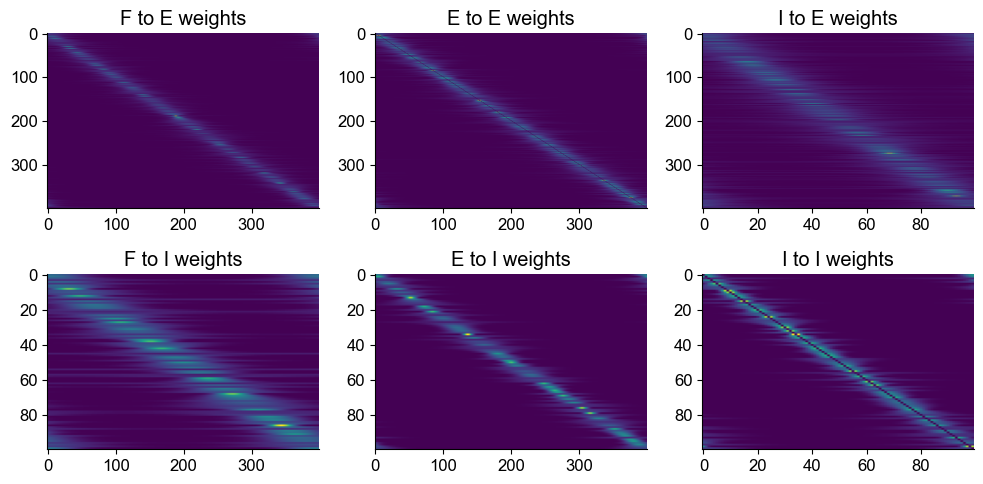

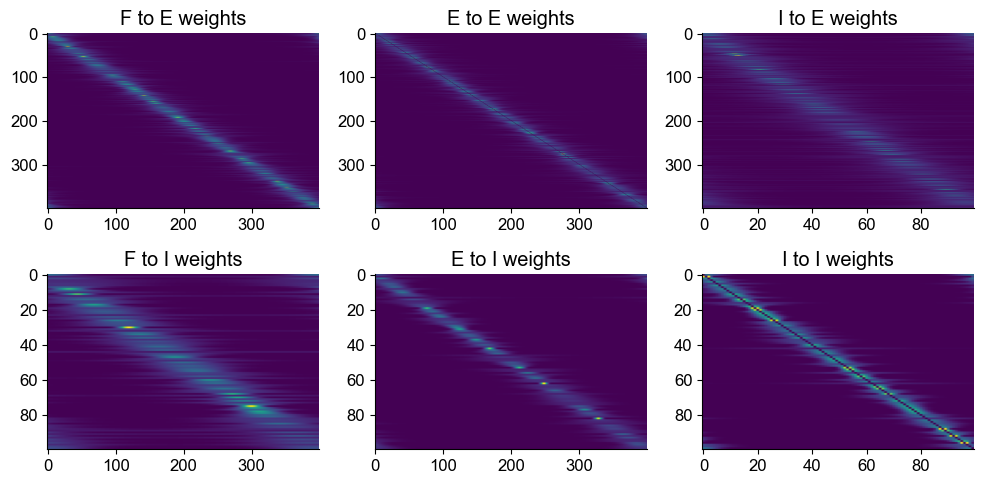

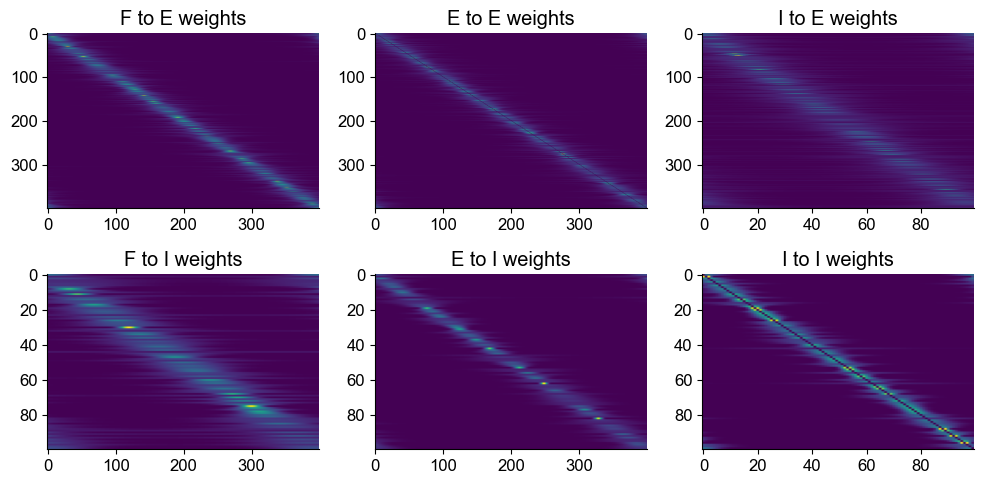

In [4]:
net_inh_1 = BaselineNetwork(inh_type="co-tuned", E_to_E="on", E_to_I="on", I_to_I="on",
                      plasticity_E_to_E="off", plasticity_E_to_I="off", plasticity_I_to_E="off", plasticity_I_to_I="off",
                      plasticity_F_to_I="on",
                      norm=True, set_seed=True, seed=42, 
                      inh_scale=0.3)
net_inh_1.run()

net_inh_2 = BaselineNetwork(inh_type="co-tuned", E_to_E="on", E_to_I="on", I_to_I="on",
                      plasticity_E_to_E="off", plasticity_E_to_I="off", plasticity_I_to_E="off", plasticity_I_to_I="off",
                      plasticity_F_to_I="on", 
                      norm=True, set_seed=True, seed=42, 
                      inh_scale=0.6)
net_inh_2.run()

net_inh_3 = BaselineNetwork(inh_type="co-tuned", E_to_E="on", E_to_I="on", I_to_I="on",
                      plasticity_E_to_E="off", plasticity_E_to_I="off", plasticity_I_to_E="off", plasticity_I_to_I="off",
                      plasticity_F_to_I="on",
                      norm=True, set_seed=True, seed=42, 
                      inh_scale=0.9)
net_inh_3.run()

In [5]:
drift_mag_1, drift_rate_1, convergence_1 = net_inh_1.get_drift_metrics()
drift_mag_2, drift_rate_2, convergence_2 = net_inh_2.get_drift_metrics()
drift_mag_3, drift_rate_3, convergence_3 = net_inh_3.get_drift_metrics()

/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_42217/2923930575.py:2: RuntimeWarning: Mean of empty slice
  axs[0].plot(np.nanmean(drift_mag_1, axis=1), marker='o', label="I scale = 0.3")
/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_42217/2923930575.py:3: RuntimeWarning: Mean of empty slice
  axs[0].plot(np.nanmean(drift_mag_2, axis=1), marker='o', label="I scale = 0.6")
/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_42217/2923930575.py:4: RuntimeWarning: Mean of empty slice
  axs[0].plot(np.nanmean(drift_mag_3, axis=1), marker='o', label="I scale = 0.9")
/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_42217/2923930575.py:10: RuntimeWarning: Mean of empty slice
  axs[1].plot(np.nanmean(drift_rate_1, axis=1), marker='o', label="I scale = 0.3")
/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_42217/2923930575.py:11: RuntimeWarning: Mean of empty slice
  axs[1].plot(np.nanmean(drift_rate_2, axis=1), marker='o', label="I scale = 0.

(-1.0, 5.0)

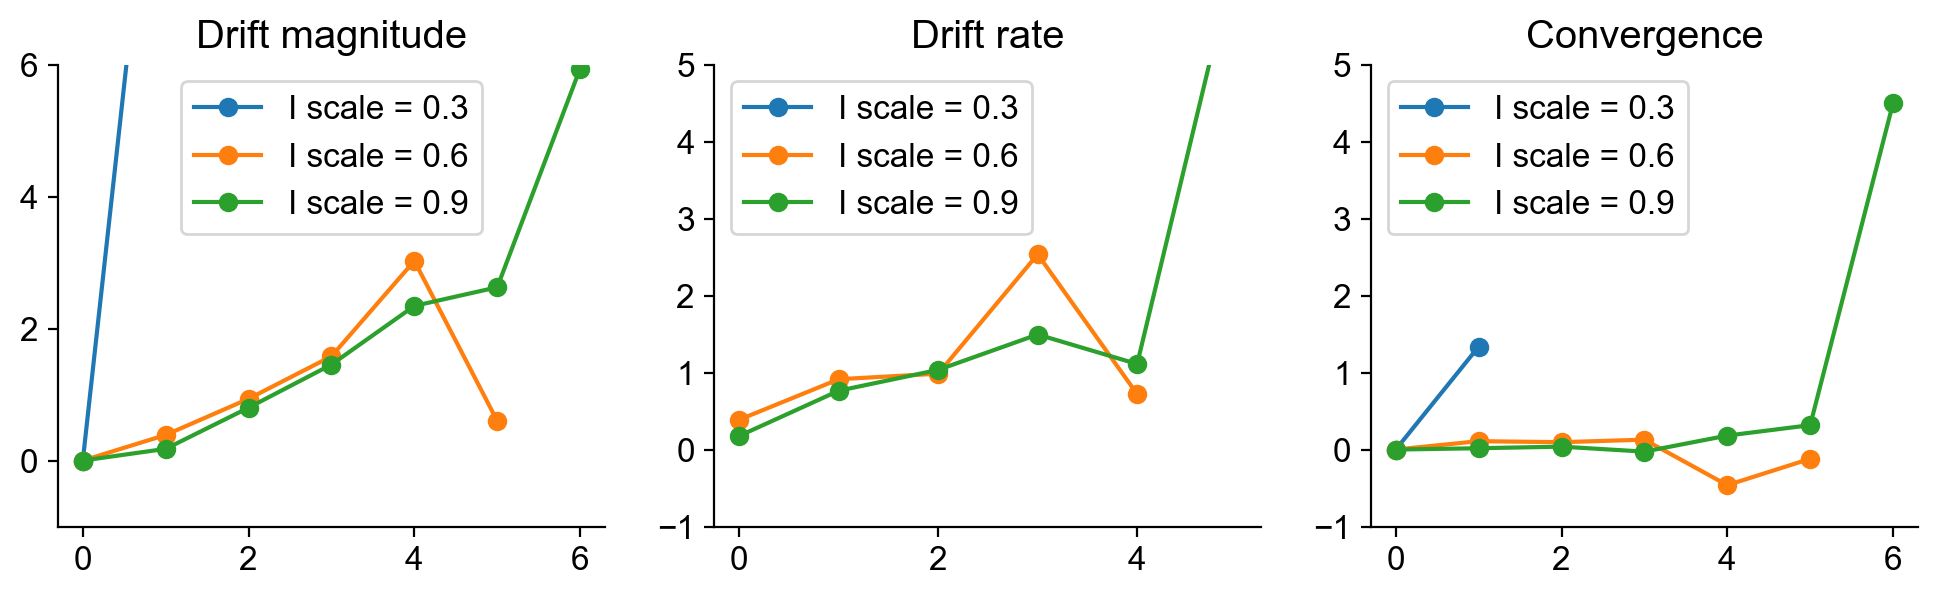

In [6]:
fig, axs = plt.subplots(1,3, figsize=(12, 3), dpi=200)
axs[0].plot(np.nanmean(drift_mag_1, axis=1), marker='o', label="I scale = 0.3")
axs[0].plot(np.nanmean(drift_mag_2, axis=1), marker='o', label="I scale = 0.6")
axs[0].plot(np.nanmean(drift_mag_3, axis=1), marker='o', label="I scale = 0.9")
axs[0].set_title("Drift magnitude")
axs[0].legend()
axs[0].set_ylim([-1, 6])


axs[1].plot(np.nanmean(drift_rate_1, axis=1), marker='o', label="I scale = 0.3")
axs[1].plot(np.nanmean(drift_rate_2, axis=1), marker='o', label="I scale = 0.6")
axs[1].plot(np.nanmean(drift_rate_3, axis=1), marker='o', label="I scale = 0.9")
axs[1].set_title("Drift rate")
axs[1].legend()
axs[1].set_ylim([-1, 5])

axs[2].plot(np.nanmean(convergence_1, axis=1), marker='o', label="I scale = 0.3")
axs[2].plot(np.nanmean(convergence_2, axis=1), marker='o', label="I scale = 0.6")
axs[2].plot(np.nanmean(convergence_3, axis=1), marker='o', label="I scale = 0.9")
axs[2].set_title("Convergence")
axs[2].legend()
axs[2].set_ylim([-1, 5])


In [7]:
activity_1 = net_inh_1.estimate_activity_at_day(90, 10)
activity_2 = net_inh_2.estimate_activity_at_day(90, 10)
activity_3 = net_inh_3.estimate_activity_at_day(90, 10)

Text(0.5, 1.0, 'Estimated activity at day 90')

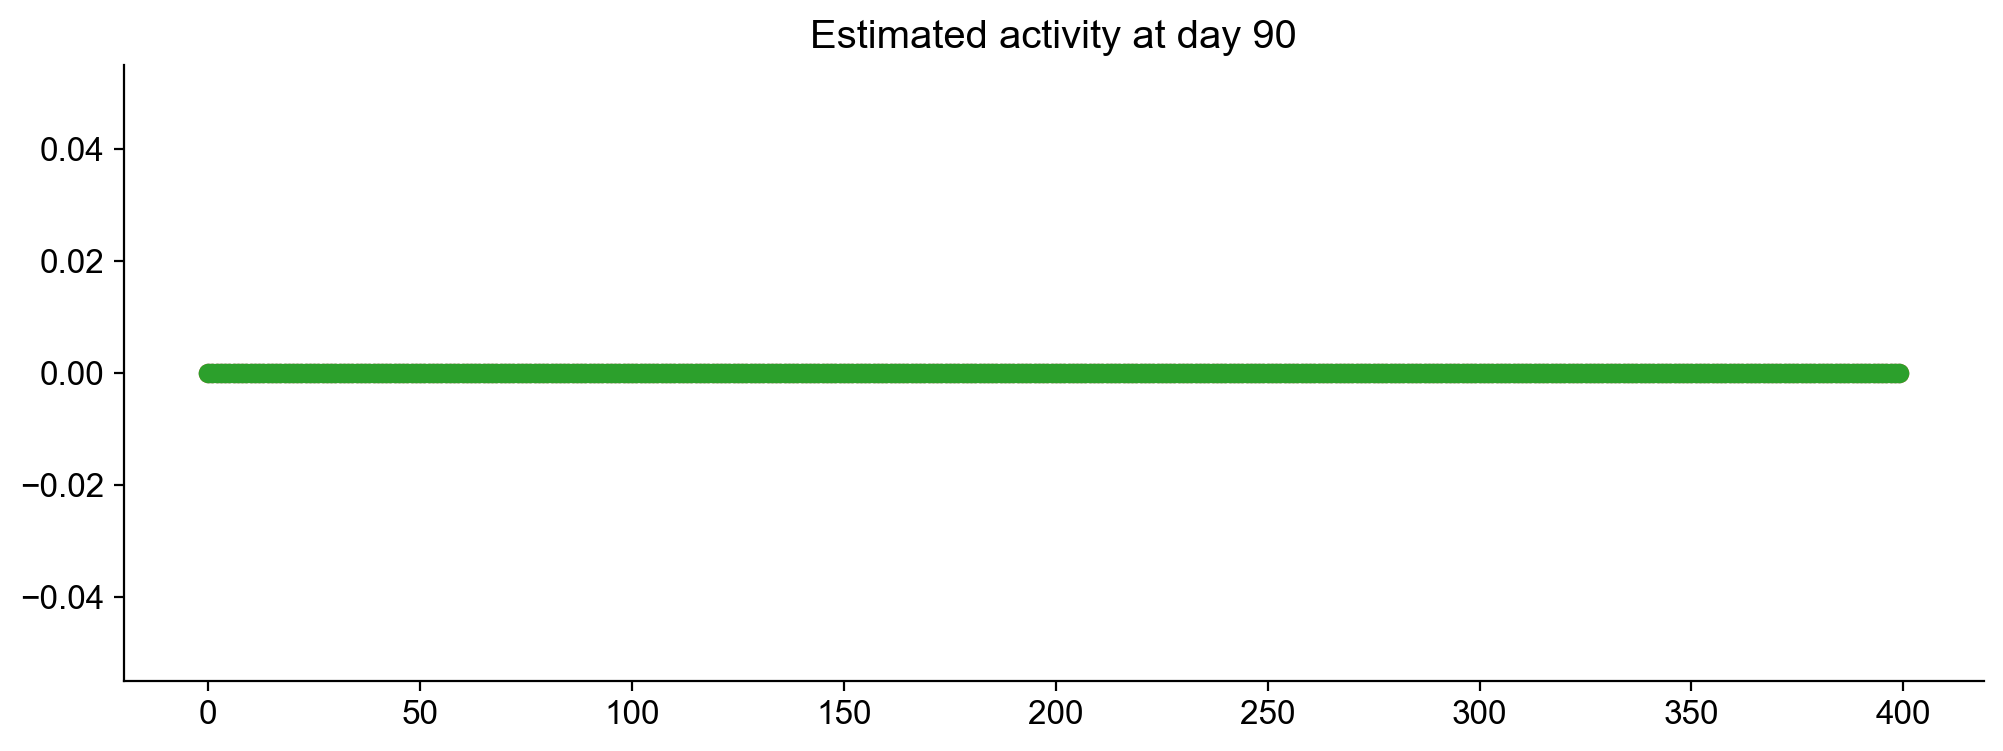

In [8]:
activity_1 = activity_1[0]
activity_2 = activity_2[0]
activity_3 = activity_3[0]

plt.figure(dpi=200, figsize=(12,4))
plt.plot(activity_1, marker='o', label="I scale = 0.3")
plt.plot(activity_2, marker='o', label="I scale = 0.6")
plt.plot(activity_3, marker='o', label="I scale = 0.9")
plt.title("Estimated activity at day 90") 

In [9]:
# plot drift magnitude vs assigned weight width (vars_ef)
 
fig, axs = plt.subplots(1,3, figsize=(12, 3), dpi=200, sharex=True, sharey=True)

axs[0].scatter(net_inh_1.vars_ef, drift_mag_1[-1])
axs[0].set_xlabel("Assigned Weight Width")
axs[0].set_ylabel("Drift Magnitude")
axs[0].set_title("I scale = 0.3")
axs[0].legend()
axs[0].set_xscale('log')
axs[0].set_yscale('log')

axs[1].scatter(net_inh_2.vars_ef, drift_mag_2[-1])
axs[1].set_xlabel("Assigned Weight Width")
axs[1].set_title("I scale = 0.6")
axs[1].legend()
axs[1].set_xscale('log')
axs[1].set_yscale('log')

axs[2].scatter(net_inh_3.vars_ef, drift_mag_3[-1])
axs[2].set_xlabel("Assigned Weight Width") 
axs[2].set_title("I scale = 0.9")
axs[2].legend()
axs[2].set_xscale('log')
axs[2].set_yscale('log')




/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_42217/3805885358.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()
/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_42217/3805885358.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend()
/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_42217/3805885358.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[2].legend()


Error in callback <function _draw_all_if_interactive at 0x1174789a0> (for post_execute), with arguments args (),kwargs {}:


ValueError: Data has no positive values, and therefore cannot be log-scaled.

ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 2400x600 with 3 Axes>